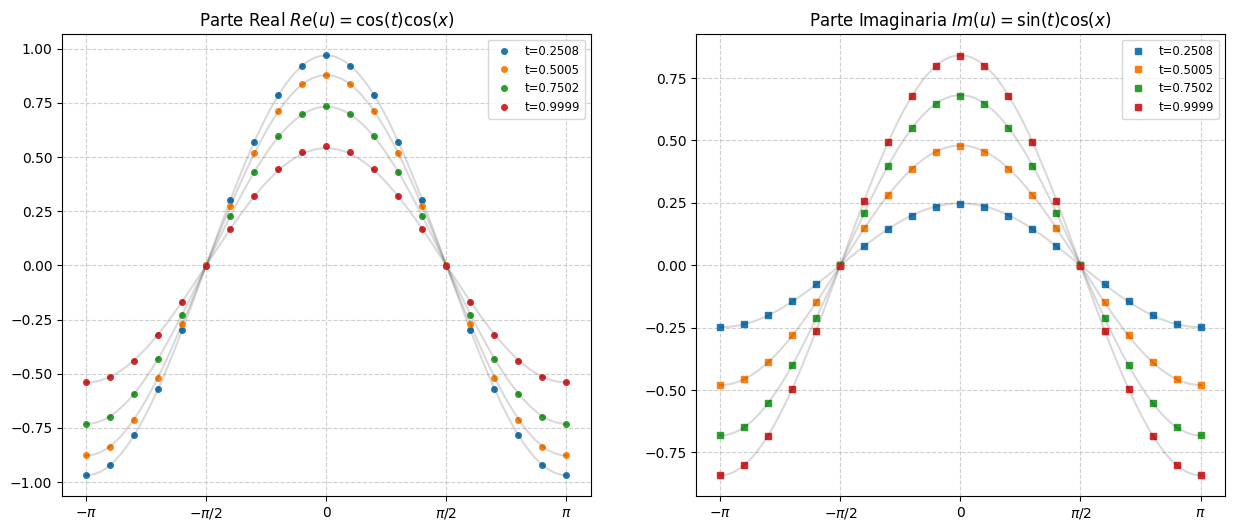

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar datos
data = np.loadtxt('resultados_2.dat', comments='#')
t_data, x_data = data[:, 0], data[:, 1]
re_num, im_num = data[:, 2], data[:, 3]

# 2. Definir los tiempos que quieres visualizar
tiempos_objetivo = [0.2509, 0.5005, 0.7501, 0.9997]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

for t_obj in tiempos_objetivo:
    # Encontrar el índice del tiempo más cercano en el archivo
    idx = (np.abs(t_data - t_obj)).argmin()
    t_encontrado = t_data[idx]
    
    # Crear máscara para extraer solo los puntos de ese instante
    mask = np.isclose(t_data, t_encontrado, atol=1e-5)
    
    # Puntos numéricos (Fortran)
    ax1.plot(x_data[mask], re_num[mask], 'o', markersize=4, label=f't={t_encontrado:.4f}')
    ax2.plot(x_data[mask], im_num[mask], 's', markersize=4, label=f't={t_encontrado:.4f}')
    
    # Curva exacta para comparación visual (sin puntos)
    x_exact = np.linspace(-np.pi, np.pi, 200)
    ax1.plot(x_exact, np.cos(t_encontrado) * np.cos(x_exact), 'k-', alpha=0.15)
    ax2.plot(x_exact, np.sin(t_encontrado) * np.cos(x_exact), 'k-', alpha=0.15)

# Estética
for ax in [ax1, ax2]:
    ax.set_xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi])
    ax.set_xticklabels([r'$-\pi$', r'$-\pi/2$', '0', r'$\pi/2$', r'$\pi$'])
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(fontsize='small')

ax1.set_title(r'Parte Real $Re(u) = \cos(t)\cos(x)$')
ax2.set_title(r'Parte Imaginaria $Im(u) = \sin(t)\cos(x)$')
plt.show()

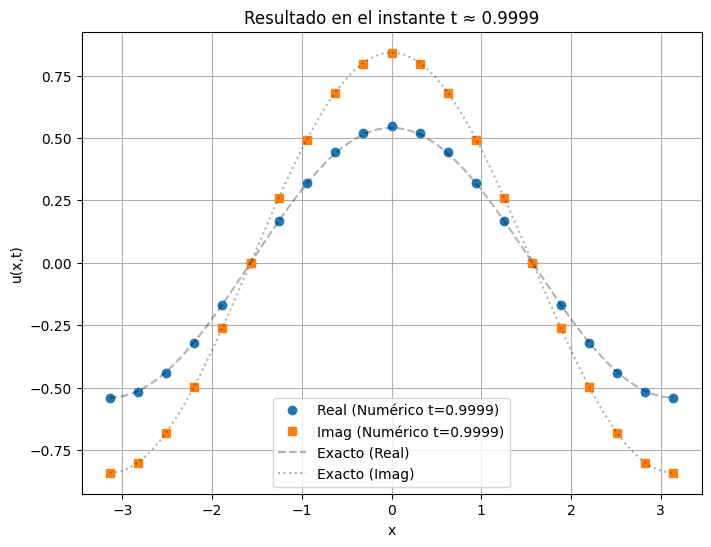

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset
data = np.loadtxt('resultados_2.dat', comments='#')
t_data, x_data = data[:, 0], data[:, 1]
re_num, im_num = data[:, 2], data[:, 3]

# 2. Define AQUÍ el tiempo exacto que quieres graficar
tiempo_deseado = 0.9997 

# 3. Buscar el tiempo más cercano en el archivo
idx = (np.abs(t_data - tiempo_deseado)).argmin()
t_real = t_data[idx]

# 4. Crear máscara para ese tiempo
mask = np.isclose(t_data, t_real, atol=1e-5)

# 5. Graficar
plt.figure(figsize=(8, 6))

# Datos numéricos
plt.plot(x_data[mask], re_num[mask], 'o', label=f'Real (Numérico t={t_real:.4f})')
plt.plot(x_data[mask], im_num[mask], 's', label=f'Imag (Numérico t={t_real:.4f})')

# Curva exacta de referencia
x_exact = np.linspace(-np.pi, np.pi, 200)
plt.plot(x_exact, np.cos(t_real) * np.cos(x_exact), 'k--', alpha=0.3, label='Exacto (Real)')
plt.plot(x_exact, np.sin(t_real) * np.cos(x_exact), 'k:', alpha=0.3, label='Exacto (Imag)')

plt.title(f'Resultado en el instante t ≈ {t_real:.4f}')
plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.grid(True)
plt.legend()
plt.show()

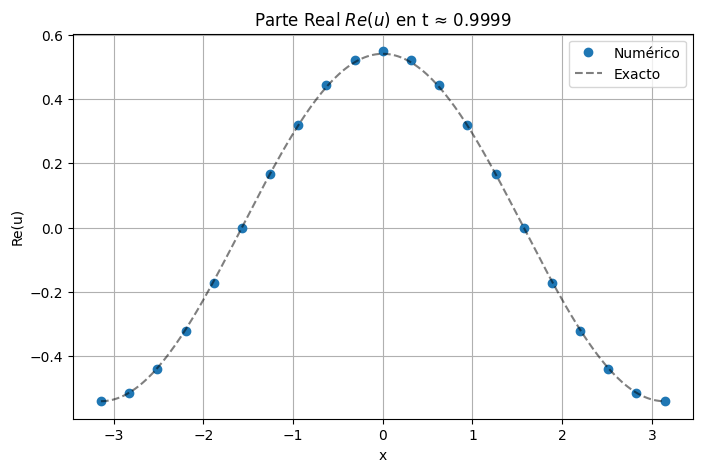

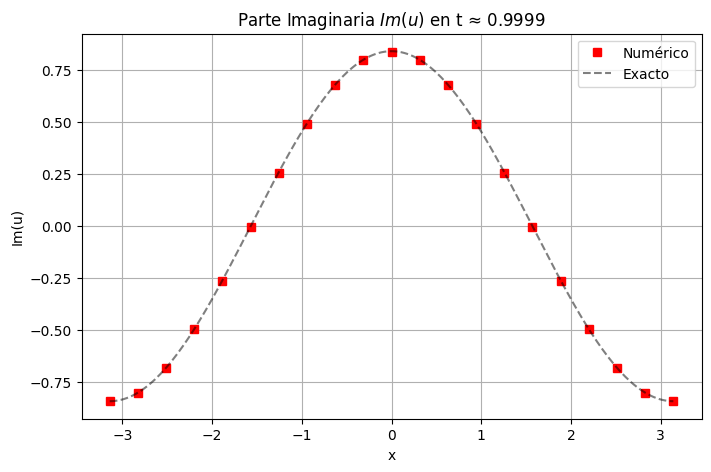

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar el dataset
data = np.loadtxt('resultados_2.dat', comments='#')
t_data, x_data = data[:, 0], data[:, 1]
re_num, im_num = data[:, 2], data[:, 3]

# 2. Definir el tiempo que quieres visualizar
tiempo_deseado = 0.9997 

# Buscar el tiempo real en el archivo
idx = (np.abs(t_data - tiempo_deseado)).argmin()
t_real = t_data[idx]
mask = np.isclose(t_data, t_real, atol=1e-5)

# Crear dos figuras separadas
fig1, ax1 = plt.subplots(figsize=(8, 5))
fig2, ax2 = plt.subplots(figsize=(8, 5))

# --- GRÁFICA PARTE REAL ---
ax1.plot(x_data[mask], re_num[mask], 'o', label='Numérico')
x_exact = np.linspace(-np.pi, np.pi, 200)
ax1.plot(x_exact, np.cos(t_real) * np.cos(x_exact), 'k--', alpha=0.5, label='Exacto')
ax1.set_title(f'Parte Real $Re(u)$ en t ≈ {t_real:.4f}')
ax1.set_xlabel('x')
ax1.set_ylabel('Re(u)')
ax1.grid(True)
ax1.legend()

# --- GRÁFICA PARTE IMAGINARIA ---
ax2.plot(x_data[mask], im_num[mask], 's', color='red', label='Numérico')
ax2.plot(x_exact, np.sin(t_real) * np.cos(x_exact), 'k--', alpha=0.5, label='Exacto')
ax2.set_title(f'Parte Imaginaria $Im(u)$ en t ≈ {t_real:.4f}')
ax2.set_xlabel('x')
ax2.set_ylabel('Im(u)')
ax2.grid(True)
ax2.legend()

plt.show()